This notebook is a part of the master thesis of Kjersti Stangeland, University of Oslo.
*2024-2026*

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
from funcs import *
from clean_and_combine import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_20cm_week47_48/Probe_noise/')

%load_ext autoreload
%autoreload 2

# Probe noise

**Check that the type and serial number is correct!**
The water level measurements were done with four acoustic probes of the type: *USS02/HFP* from *General Acoustics*. The probe settings used were:
* Sample rate of 250 Hz
* Resolution: 0.18 mm
* Accuracy??

The signals recorded by the probes were processed by a software named *UltraLab Advanced Controller*, which converts the acoustic signal to distance in meters. Further, the processed data is sent to *UltraLab: Ultralab Monitoring Software* which displays the data and allows for saving the experiment runs.

### Noise measurement
The 27th of November 2025, I conducted a probe noise measurement. For 120 seconds, the four probes recorded the water level of stil water at 20 cm depth. 

In [3]:
path = '/Users/kjesta/Desktop/LABDATA/Kjersti_20cm_week47_48/Probe_noise/probe_noise_271125.csv'
df = pd.read_csv(path)

headers = ['time', 'P_0', 'P_1', 'P_2', 'P_3', 'sound_speed']
df.columns = headers

In [4]:
df

,time,P_0,P_1,P_2,P_3,sound_speed
0,11/27/2025 16:03:49.492,0.27363,0.27286,0.27372,0.27329,343.12
1,11/27/2025 16:03:49.496,0.27363,0.27278,0.27372,0.27329,343.12
2,11/27/2025 16:03:49.500,0.27363,0.27286,0.27372,0.27329,343.12
3,11/27/2025 16:03:49.504,0.27372,0.27286,0.27372,0.27329,343.12
4,11/27/2025 16:03:49.508,0.27372,0.27286,0.27372,0.27329,343.12
...,...,...,...,...,...,...
31324,11/27/2025 16:05:54.788,0.27363,0.27286,0.27372,0.27338,343.12
31325,11/27/2025 16:05:54.792,0.27363,0.27286,0.27372,0.27329,343.12
31326,11/27/2025 16:05:54.796,0.27363,0.27286,0.27372,0.27329,343.12
31327,11/27/2025 16:05:54.800,0.27363,0.27286,0.27363,0.27329,343.12


In [32]:
# Mean of each probe, raw data
mean_P0_raw = np.mean(df['P_0'])
mean_P1_raw = np.mean(df['P_1'])
mean_P2_raw = np.mean(df['P_2'])
mean_P3_raw = np.mean(df['P_3'])

Text(0.5, 0.98, 'Probe Noise Signals (No Wave Generation)')

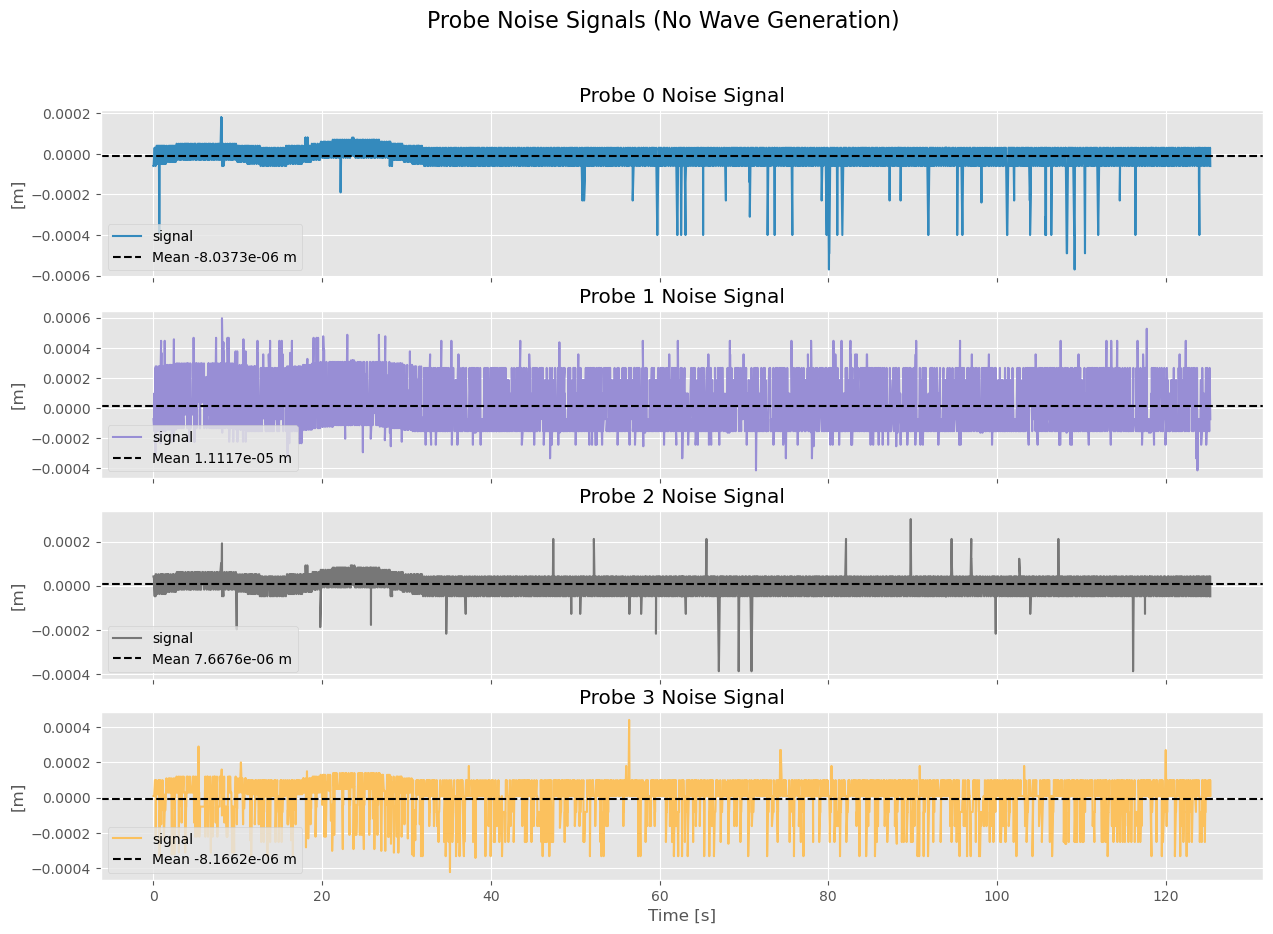

In [33]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax[0].plot(df['time'], df['P_0'], label='signal', color='C1')
ax[0].axhline(mean_P0_raw, color='k', linestyle='--', label=f'Mean {mean_P0_raw:.4e} m')
ax[0].legend(loc='lower left')
ax[0].set_ylabel('[m]')
ax[0].set_title('Probe 0 Noise Signal')

ax[1].plot(df['time'], df['P_1'], label='signal', color='C2')
ax[1].axhline(mean_P1_raw, color='k', linestyle='--', label=f'Mean {mean_P1_raw:.4e} m')
ax[1].legend(loc='lower left')
ax[1].set_ylabel('[m]')
ax[1].set_title('Probe 1 Noise Signal')

ax[2].plot(df['time'], df['P_2'], label='signal', color='C3')
ax[2].axhline(mean_P2_raw, color='k', linestyle='--', label=f'Mean {mean_P2_raw:.4e} m')
ax[2].legend(loc='lower left')
ax[2].set_ylabel('[m]')
ax[2].set_title('Probe 2 Noise Signal')

ax[3].plot(df['time'], df['P_3'], label='signal', color='C4')
ax[3].axhline(mean_P3_raw, color='k', linestyle='--', label=f'Mean {mean_P3_raw:.4e} m')
ax[3].legend(loc='lower left')
ax[3].set_xlabel('Time [s]')
ax[3].set_ylabel('[m]') 
ax[3].set_title('Probe 3 Noise Signal')

fig.suptitle('Probe Noise Signals (No Wave Generation)', fontsize=16)

Text(0.5, 0.98, 'Probe Noise Signals (No Wave Generation) - Zoomed In')

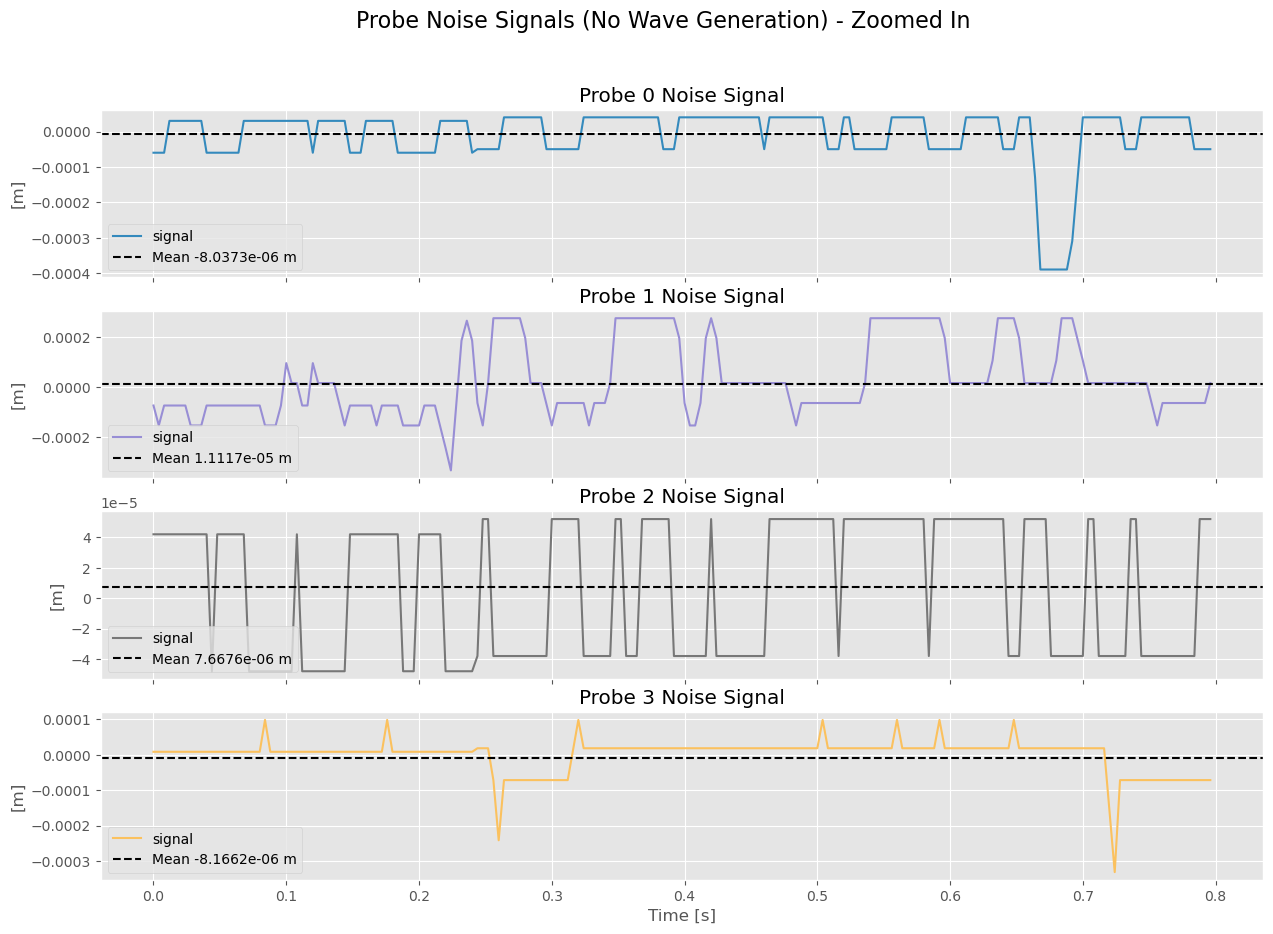

In [35]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax[0].plot(df['time'][0:200], df['P_0'][0:200], label='signal', color='C1')
ax[0].axhline(mean_P0_raw, color='k', linestyle='--', label=f'Mean {mean_P0_raw:.4e} m')
ax[0].set_ylabel('[m]')
ax[0].set_title('Probe 0 Noise Signal')
ax[0].legend(loc='lower left')

ax[1].plot(df['time'][0:200], df['P_1'][0:200], label='signal', color='C2')
ax[1].axhline(mean_P1_raw, color='k', linestyle='--', label=f'Mean {mean_P1_raw:.4e} m')
ax[1].set_ylabel('[m]')
ax[1].set_title('Probe 1 Noise Signal')
ax[1].legend(loc='lower left')

ax[2].plot(df['time'][0:200], df['P_2'][0:200], label='signal', color='C3')
ax[2].axhline(mean_P2_raw, color='k', linestyle='--', label=f'Mean {mean_P2_raw:.4e} m')
ax[2].set_ylabel('[m]')
ax[2].set_title('Probe 2 Noise Signal')
ax[2].legend(loc='lower left')

ax[3].plot(df['time'][0:200], df['P_3'][0:200], label='signal', color='C4')
ax[3].axhline(mean_P3_raw, color='k', linestyle='--', label=f'Mean {mean_P3_raw:.4e} m')
ax[3].set_xlabel('Time [s]')
ax[3].set_ylabel('[m]') 
ax[3].set_title('Probe 3 Noise Signal')
ax[3].legend(loc='lower left')

fig.suptitle('Probe Noise Signals (No Wave Generation) - Zoomed In', fontsize=16)

## Magnitude of noise per probe

In [44]:
std_P0 = np.std(df['P_0'])
std_P1 = np.std(df['P_1'])
std_P2 = np.std(df['P_2'])
std_P3 = np.std(df['P_3'])

In [48]:
print(f'Standard Deviation Probe 0: {std_P0:.6f} m = {std_P0*1000:.2f} mm')
print(f'Standard Deviation Probe 1: {std_P1:.6f} m = {std_P1*1000:.2f} mm')
print(f'Standard Deviation Probe 2: {std_P2:.6f} m = {std_P2*1000:.2f} mm')
print(f'Standard Deviation Probe 3: {std_P3:.6f} m = {std_P3*1000:.2f} mm')

Standard Deviation Probe 0: 0.000062 m = 0.06 mm
Standard Deviation Probe 1: 0.000143 m = 0.14 mm
Standard Deviation Probe 2: 0.000049 m = 0.05 mm
Standard Deviation Probe 3: 0.000053 m = 0.05 mm


Signals larger than the standard deviation of the probe can be trusted as a true signal, and not a probe artefact.

# How post processing affects the signal
1) Cleaning - taking off the mean of the probes
2) Filtering
3) Detrending

In [17]:
clean = clean(df)

In [26]:
# Mean of each probe after cleaning
mean_P0_clean = np.mean(clean['P_0'])
mean_P1_clean = np.mean(clean['P_1'])
mean_P2_clean = np.mean(clean['P_2'])
mean_P3_clean = np.mean(clean['P_3'])

Text(0.5, 0.98, 'Cleaned Probe Noise Signals (No Wave Generation) - Zoomed In')

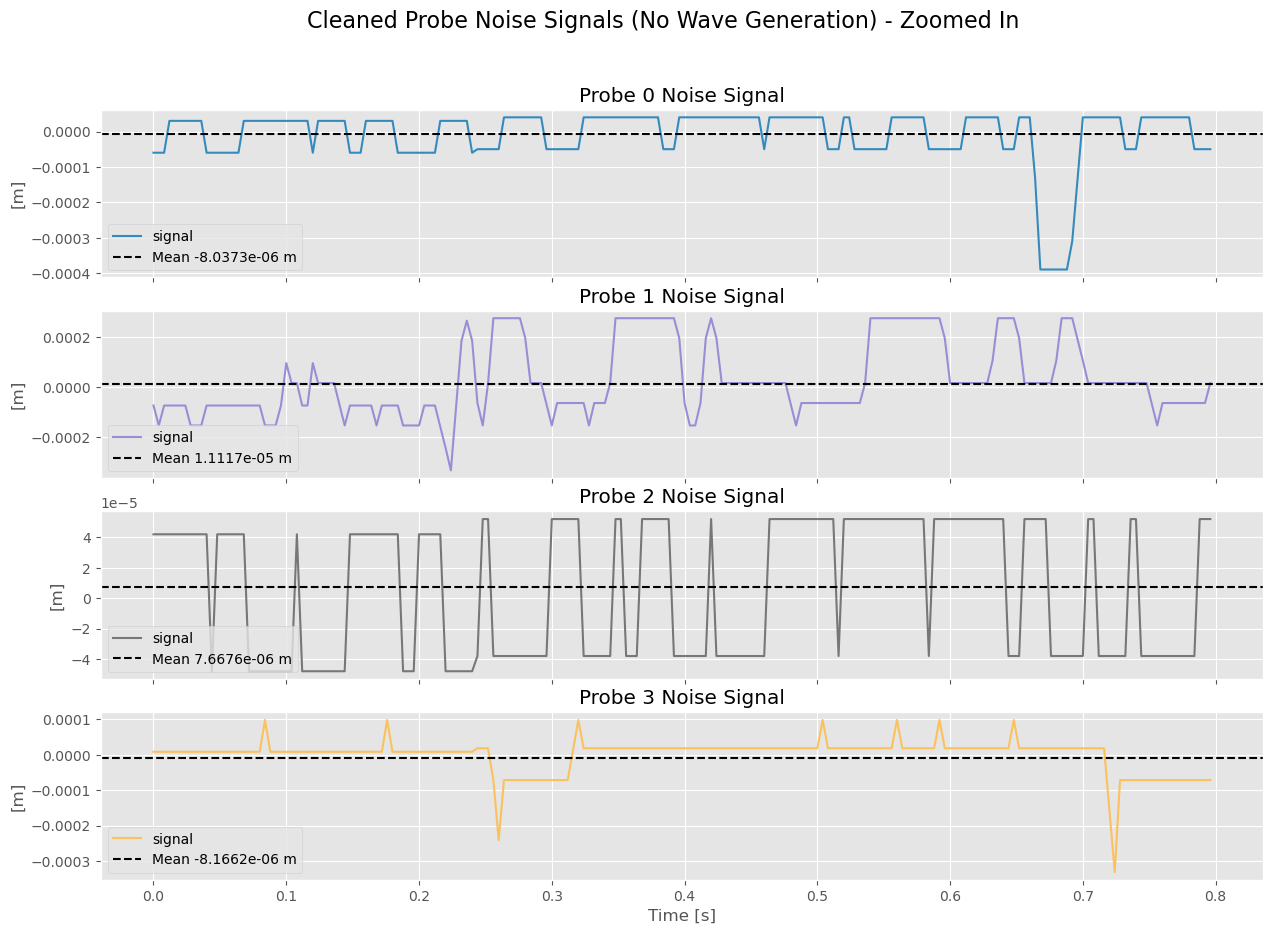

In [36]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax[0].plot(clean['time'][0:200], clean['P_0'][0:200], label = 'signal', color='C1')
ax[0].set_ylabel('[m]')
ax[0].set_title('Probe 0 Noise Signal')
ax[0].axhline(mean_P0_clean, color='k', linestyle='--', label=f'Mean {mean_P0_clean:.4e} m')
ax[0].legend(loc='lower left')

ax[1].plot(clean['time'][0:200], clean['P_1'][0:200], label = 'signal', color='C2')
ax[1].set_ylabel('[m]')
ax[1].set_title('Probe 1 Noise Signal')
ax[1].axhline(mean_P1_clean, color='k', linestyle='--', label=f'Mean {mean_P1_clean:.4e} m')
ax[1].legend(loc='lower left')

ax[2].plot(clean['time'][0:200], clean['P_2'][0:200], label = 'signal', color='C3')
ax[2].set_ylabel('[m]')
ax[2].set_title('Probe 2 Noise Signal')
ax[2].axhline(mean_P2_clean, color='k', linestyle='--', label=f'Mean {mean_P2_clean:.4e} m')
ax[2].legend(loc='lower left')

ax[3].plot(clean['time'][0:200], clean['P_3'][0:200], label = 'signal', color='C4')
ax[3].set_xlabel('Time [s]')
ax[3].set_ylabel('[m]') 
ax[3].set_title('Probe 3 Noise Signal')
ax[3].axhline(mean_P3_clean, color='k', linestyle='--', label=f'Mean {mean_P3_clean:.4e} m')
ax[3].legend(loc='lower left')

fig.suptitle('Cleaned Probe Noise Signals (No Wave Generation) - Zoomed In', fontsize=16)

In [19]:
filtered = low_pass(clean)

In [31]:
# Mean of each probe after cleaning and filtering
mean_P0_filtered = np.mean(filtered['P_0'])
mean_P1_filtered = np.mean(filtered['P_1'])
mean_P2_filtered = np.mean(filtered['P_2'])
mean_P3_filtered = np.mean(filtered['P_3'])

Text(0.5, 0.98, 'Filtered Probe Noise Signals (No Wave Generation) - Zoomed In')

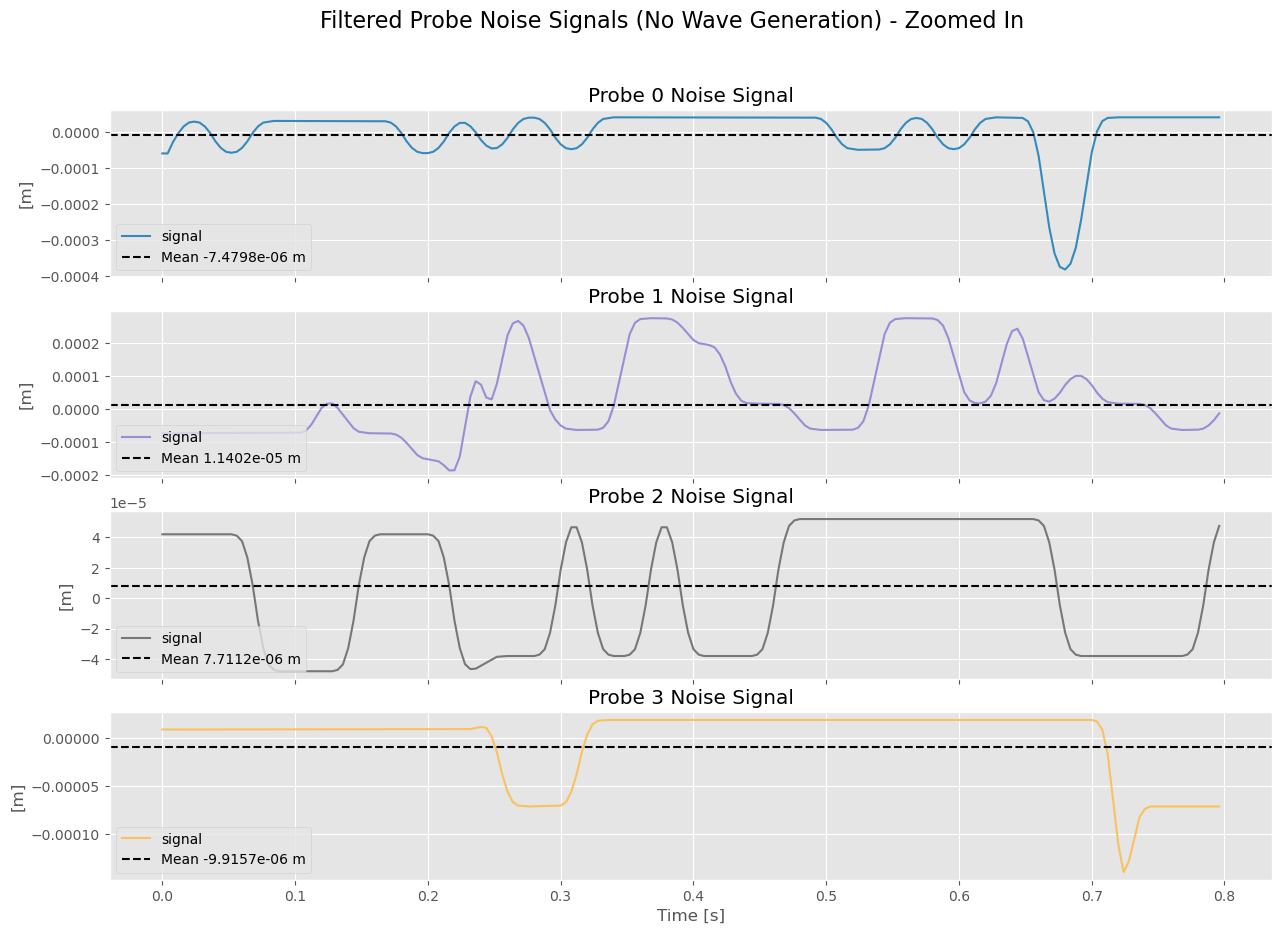

In [39]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax[0].plot(filtered['time'][0:200], filtered['P_0'][0:200], label='signal', color='C1')
ax[0].axhline(mean_P0_filtered, color='k', linestyle='--', label=f'Mean {mean_P0_filtered:.4e} m')
ax[0].set_ylabel('[m]')
ax[0].set_title('Probe 0 Noise Signal')
ax[0].legend(loc='lower left')

ax[1].plot(filtered['time'][0:200], filtered['P_1'][0:200], label='signal', color='C2')
ax[1].axhline(mean_P1_filtered, color='k', linestyle='--', label=f'Mean {mean_P1_filtered:.4e} m')
ax[1].set_ylabel('[m]')
ax[1].set_title('Probe 1 Noise Signal')
ax[1].legend(loc='lower left')

ax[2].plot(filtered['time'][0:200], filtered['P_2'][0:200], label='signal', color='C3')
ax[2].axhline(mean_P2_filtered, color='k', linestyle='--', label=f'Mean {mean_P2_filtered:.4e} m')
ax[2].set_ylabel('[m]')
ax[2].set_title('Probe 2 Noise Signal')
ax[2].legend(loc='lower left')

ax[3].plot(filtered['time'][0:200], filtered['P_3'][0:200], label='signal', color='C4')
ax[3].axhline(mean_P3_filtered, color='k', linestyle='--', label=f'Mean {mean_P3_filtered:.4e} m')
ax[3].set_xlabel('Time [s]')
ax[3].set_ylabel('[m]') 
ax[3].set_title('Probe 3 Noise Signal')
ax[3].legend(loc='lower left')

fig.suptitle('Filtered Probe Noise Signals (No Wave Generation) - Zoomed In', fontsize=16)

In [40]:
detrended = detrend(filtered)

In [41]:
# Mean of each probe after cleaning and filtering and detrending
mean_P0_detrended = np.mean(detrended['P_0'])
mean_P1_detrended = np.mean(detrended['P_1'])
mean_P2_detrended = np.mean(detrended['P_2'])
mean_P3_detrended = np.mean(detrended['P_3'])

Text(0.5, 0.98, 'Detrended Probe Noise Signals (No Wave Generation) - Zoomed In')

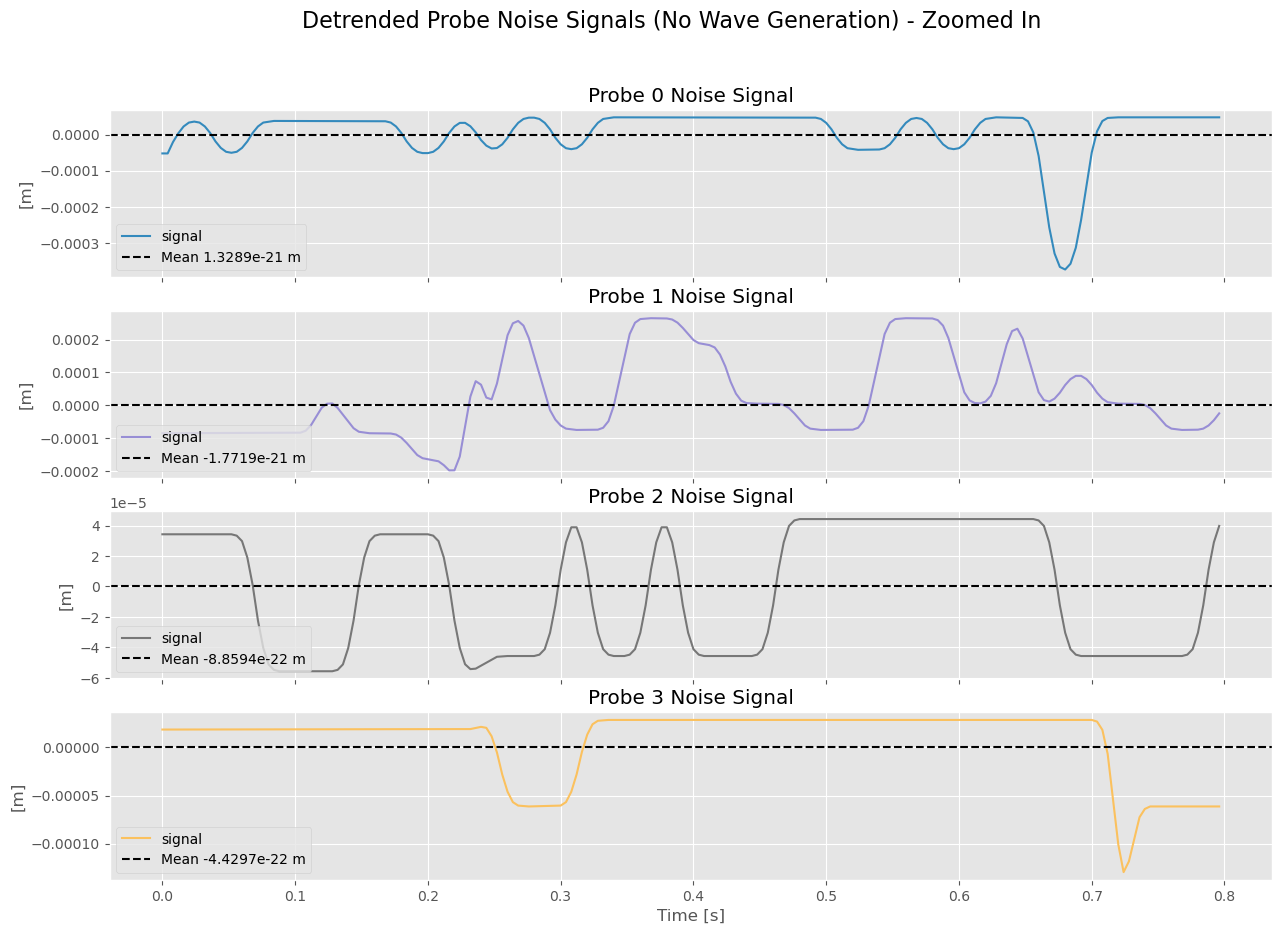

In [43]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax[0].plot(detrended['time'][0:200], detrended['P_0'][0:200], label='signal', color='C1')
ax[0].axhline(mean_P0_detrended, color='k', linestyle='--', label=f'Mean {mean_P0_detrended:.4e} m')
ax[0].set_ylabel('[m]')
ax[0].set_title('Probe 0 Noise Signal')
ax[0].legend(loc='lower left')

ax[1].plot(detrended['time'][0:200], detrended['P_1'][0:200], label='signal', color='C2')
ax[1].axhline(mean_P1_detrended, color='k', linestyle='--', label=f'Mean {mean_P1_detrended:.4e} m')
ax[1].set_ylabel('[m]')
ax[1].set_title('Probe 1 Noise Signal')
ax[1].legend(loc='lower left')

ax[2].plot(detrended['time'][0:200], detrended['P_2'][0:200], label='signal', color='C3')
ax[2].axhline(mean_P2_detrended, color='k', linestyle='--', label=f'Mean {mean_P2_detrended:.4e} m')
ax[2].set_ylabel('[m]')
ax[2].set_title('Probe 2 Noise Signal')
ax[2].legend(loc='lower left')

ax[3].plot(detrended['time'][0:200], detrended['P_3'][0:200], label='signal', color='C4')
ax[3].axhline(mean_P3_detrended, color='k', linestyle='--', label=f'Mean {mean_P3_detrended:.4e} m')
ax[3].set_xlabel('Time [s]')
ax[3].set_ylabel('[m]') 
ax[3].set_title('Probe 3 Noise Signal')
ax[3].legend(loc='lower left')

fig.suptitle('Detrended Probe Noise Signals (No Wave Generation) - Zoomed In', fontsize=16)